# Inference on the trained checkpoint

In this notebook we will visualize the results of the training and compute some metrics of importance from a scientific analysis standpoint to further evaluate the performance of the model. This notebook can be executed after the training for the model is complete.

Let's jump right in. We will start with reading the validation dataset



In [23]:
import glob
import math
import torch
import numpy as np
from torch import nn
from physicsnemo.sym.hydra.utils import compose
from physicsnemo.sym.hydra.amp import register_amp_configs
from physicsnemo.sym.key import Key
from physicsnemo.sym.hydra import instantiate_arch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Monkey-patch SRResNet to allow any power-of-2 scaling factor (needed for 16x, 32x)
import physicsnemo.models.srrn.super_res_net as _srn
from physicsnemo.models.srrn.super_res_net import (
    ConvolutionalBlock3d, ResidualConvBlock3d,
    SubPixel_ConvolutionalBlock3d, MetaData,
)
from physicsnemo.models.layers import get_activation

def _patched_init(
    self, in_channels, out_channels, large_kernel_size=7,
    small_kernel_size=3, conv_layer_size=32, n_resid_blocks=8,
    scaling_factor=8, activation_fn="prelu",
):
    _srn.Module.__init__(self, meta=MetaData())
    self.var_dim = 1
    if isinstance(activation_fn, str):
        activation_fn = get_activation(activation_fn)
    scaling_factor = int(scaling_factor)
    if scaling_factor < 2 or (scaling_factor & (scaling_factor - 1)) != 0:
        raise ValueError("The scaling factor must be a power of 2, >= 2!")
    self.conv_block1 = ConvolutionalBlock3d(
        in_channels=in_channels, out_channels=conv_layer_size,
        kernel_size=large_kernel_size, batch_norm=False, activation_fn=activation_fn,
    )
    self.residual_blocks = nn.Sequential(*[
        ResidualConvBlock3d(
            n_layers=2, kernel_size=small_kernel_size,
            conv_layer_size=conv_layer_size, activation_fn=activation_fn,
        ) for _ in range(n_resid_blocks)
    ])
    self.conv_block2 = ConvolutionalBlock3d(
        in_channels=conv_layer_size, out_channels=conv_layer_size,
        kernel_size=small_kernel_size, batch_norm=True,
    )
    n_subpixel_convolution_blocks = int(math.log2(scaling_factor))
    self.subpixel_convolutional_blocks = nn.Sequential(*[
        SubPixel_ConvolutionalBlock3d(
            kernel_size=small_kernel_size, conv_layer_size=conv_layer_size,
            scaling_factor=2,
        ) for _ in range(n_subpixel_convolution_blocks)
    ])
    self.conv_block3 = ConvolutionalBlock3d(
        in_channels=conv_layer_size, out_channels=out_channels,
        kernel_size=large_kernel_size, batch_norm=False,
    )

_srn.SRResNet.__init__ = _patched_init

register_amp_configs()
scaling_factors = [4, 8, 16, 32]

In [24]:
domain_size = 128
path = "./datasets/jhtdb_valid"
hr_files = sorted(glob.glob(path + "/*_step_1_1_1.npy"))

high_res = []
valid_files = []
for file in hr_files:
    data = np.load(file)
    if data.shape[0] != domain_size:
        continue
    high_res.append(np.rollaxis(data, -1, 0))
    valid_files.append(file)

U_hr_true = torch.from_numpy(np.stack(high_res, axis=0)).to(torch.float)

# Load low-res data for each scaling factor
U_lr = {}
for sf in scaling_factors:
    lr_step = f"step_{sf}_{sf}_{sf}"
    low_res = []
    for file in valid_files:
        data_low_res = np.load(file.replace("step_1_1_1", lr_step))
        low_res.append(np.rollaxis(data_low_res, -1, 0))
    U_lr[sf] = torch.from_numpy(np.stack(low_res, axis=0)).to(torch.float)

print(f"Loaded {len(high_res)} validation samples at {domain_size}^3")
for sf in scaling_factors:
    print(f"  {sf}x low-res: {list(U_lr[sf].shape)}")

Loaded 16 validation samples at 128^3
  4x low-res: [16, 3, 32, 32, 32]
  8x low-res: [16, 3, 16, 16, 16]
  16x low-res: [16, 3, 8, 8, 8]
  32x low-res: [16, 3, 4, 4, 4]


## Generate Model inference

Here, we will instantiate each model (4x, 8x, 16x, 32x) and run inference on the corresponding low resolution input data.

In [25]:
U_pred = {}

for sf in scaling_factors:
    cfg = compose(
        config_path="conf", config_name="config",
        overrides=[f"arch.super_res.scaling_factor={sf}"],
    )
    model = instantiate_arch(
        input_keys=[Key("U_lr", size=3)],
        output_keys=[Key("U", size=3)],
        cfg=cfg.arch.super_res,
    )
    model.make_node(name="super_res")

    ckpt_dir = "./outputs/super_resolution/" if sf == 4 else f"./outputs/arch.super_res.scaling_factor={sf}/super_resolution/"
    print(f"Loading {sf}x model from: {ckpt_dir}")
    model.load(ckpt_dir)
    model.eval().to(device)

    preds = []
    with torch.inference_mode():
        for i in range(U_lr[sf].shape[0]):
            out = model({"U_lr": U_lr[sf][i:i+1].to(device)})
            preds.append(out["U"].cpu())
    U_pred[sf] = torch.cat(preds, dim=0)

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    print(f"  pred shape: {list(U_pred[sf].shape)}")

TorchScript default is being turned off due to PyTorch version mismatch.


Loading 4x model from: ./outputs/super_resolution/


TorchScript default is being turned off due to PyTorch version mismatch.


  pred shape: [16, 3, 128, 128, 128]
Loading 8x model from: ./outputs/arch.super_res.scaling_factor=8/super_resolution/


TorchScript default is being turned off due to PyTorch version mismatch.


  pred shape: [16, 3, 128, 128, 128]
Loading 16x model from: ./outputs/arch.super_res.scaling_factor=16/super_resolution/


TorchScript default is being turned off due to PyTorch version mismatch.


  pred shape: [16, 3, 128, 128, 128]
Loading 32x model from: ./outputs/arch.super_res.scaling_factor=32/super_resolution/
  pred shape: [16, 3, 128, 128, 128]


## Pre-process the data

Here we will compute the velocity gradients and invariants (P, Q, R) for the low-res input, all four model predictions, and the ground truth.

In [26]:
from inference_utils import compute_velocity_grad, compute_p_q_r

# Use 4x low-res (32^3) as the "Low Res" reference — largest and most visually meaningful
U_lr_ref = U_lr[4]

print("Computing velocity gradients...")
U_lr_grad = compute_velocity_grad(U_lr_ref)
U_hr_true_grad = compute_velocity_grad(U_hr_true)
print("  low-res and ground truth done")

U_pred_grad = {}
for sf in scaling_factors:
    U_pred_grad[sf] = compute_velocity_grad(U_pred[sf])
    print(f"  {sf}x done")

# Compute P, Q, R invariants
p_lr, q_lr, r_lr = compute_p_q_r(U_lr_grad)
p_hr_true, q_hr_true, r_hr_true = compute_p_q_r(U_hr_true_grad)

p_pred, q_pred, r_pred = {}, {}, {}
for sf in scaling_factors:
    p_pred[sf], q_pred[sf], r_pred[sf] = compute_p_q_r(U_pred_grad[sf])

Computing velocity gradients...
  low-res and ground truth done
  4x done
  8x done
  16x done
  32x done


## Plot the raw fields

Let's start by visualizing the raw fields. We will use matplotlib to visualize a slice of the data. 


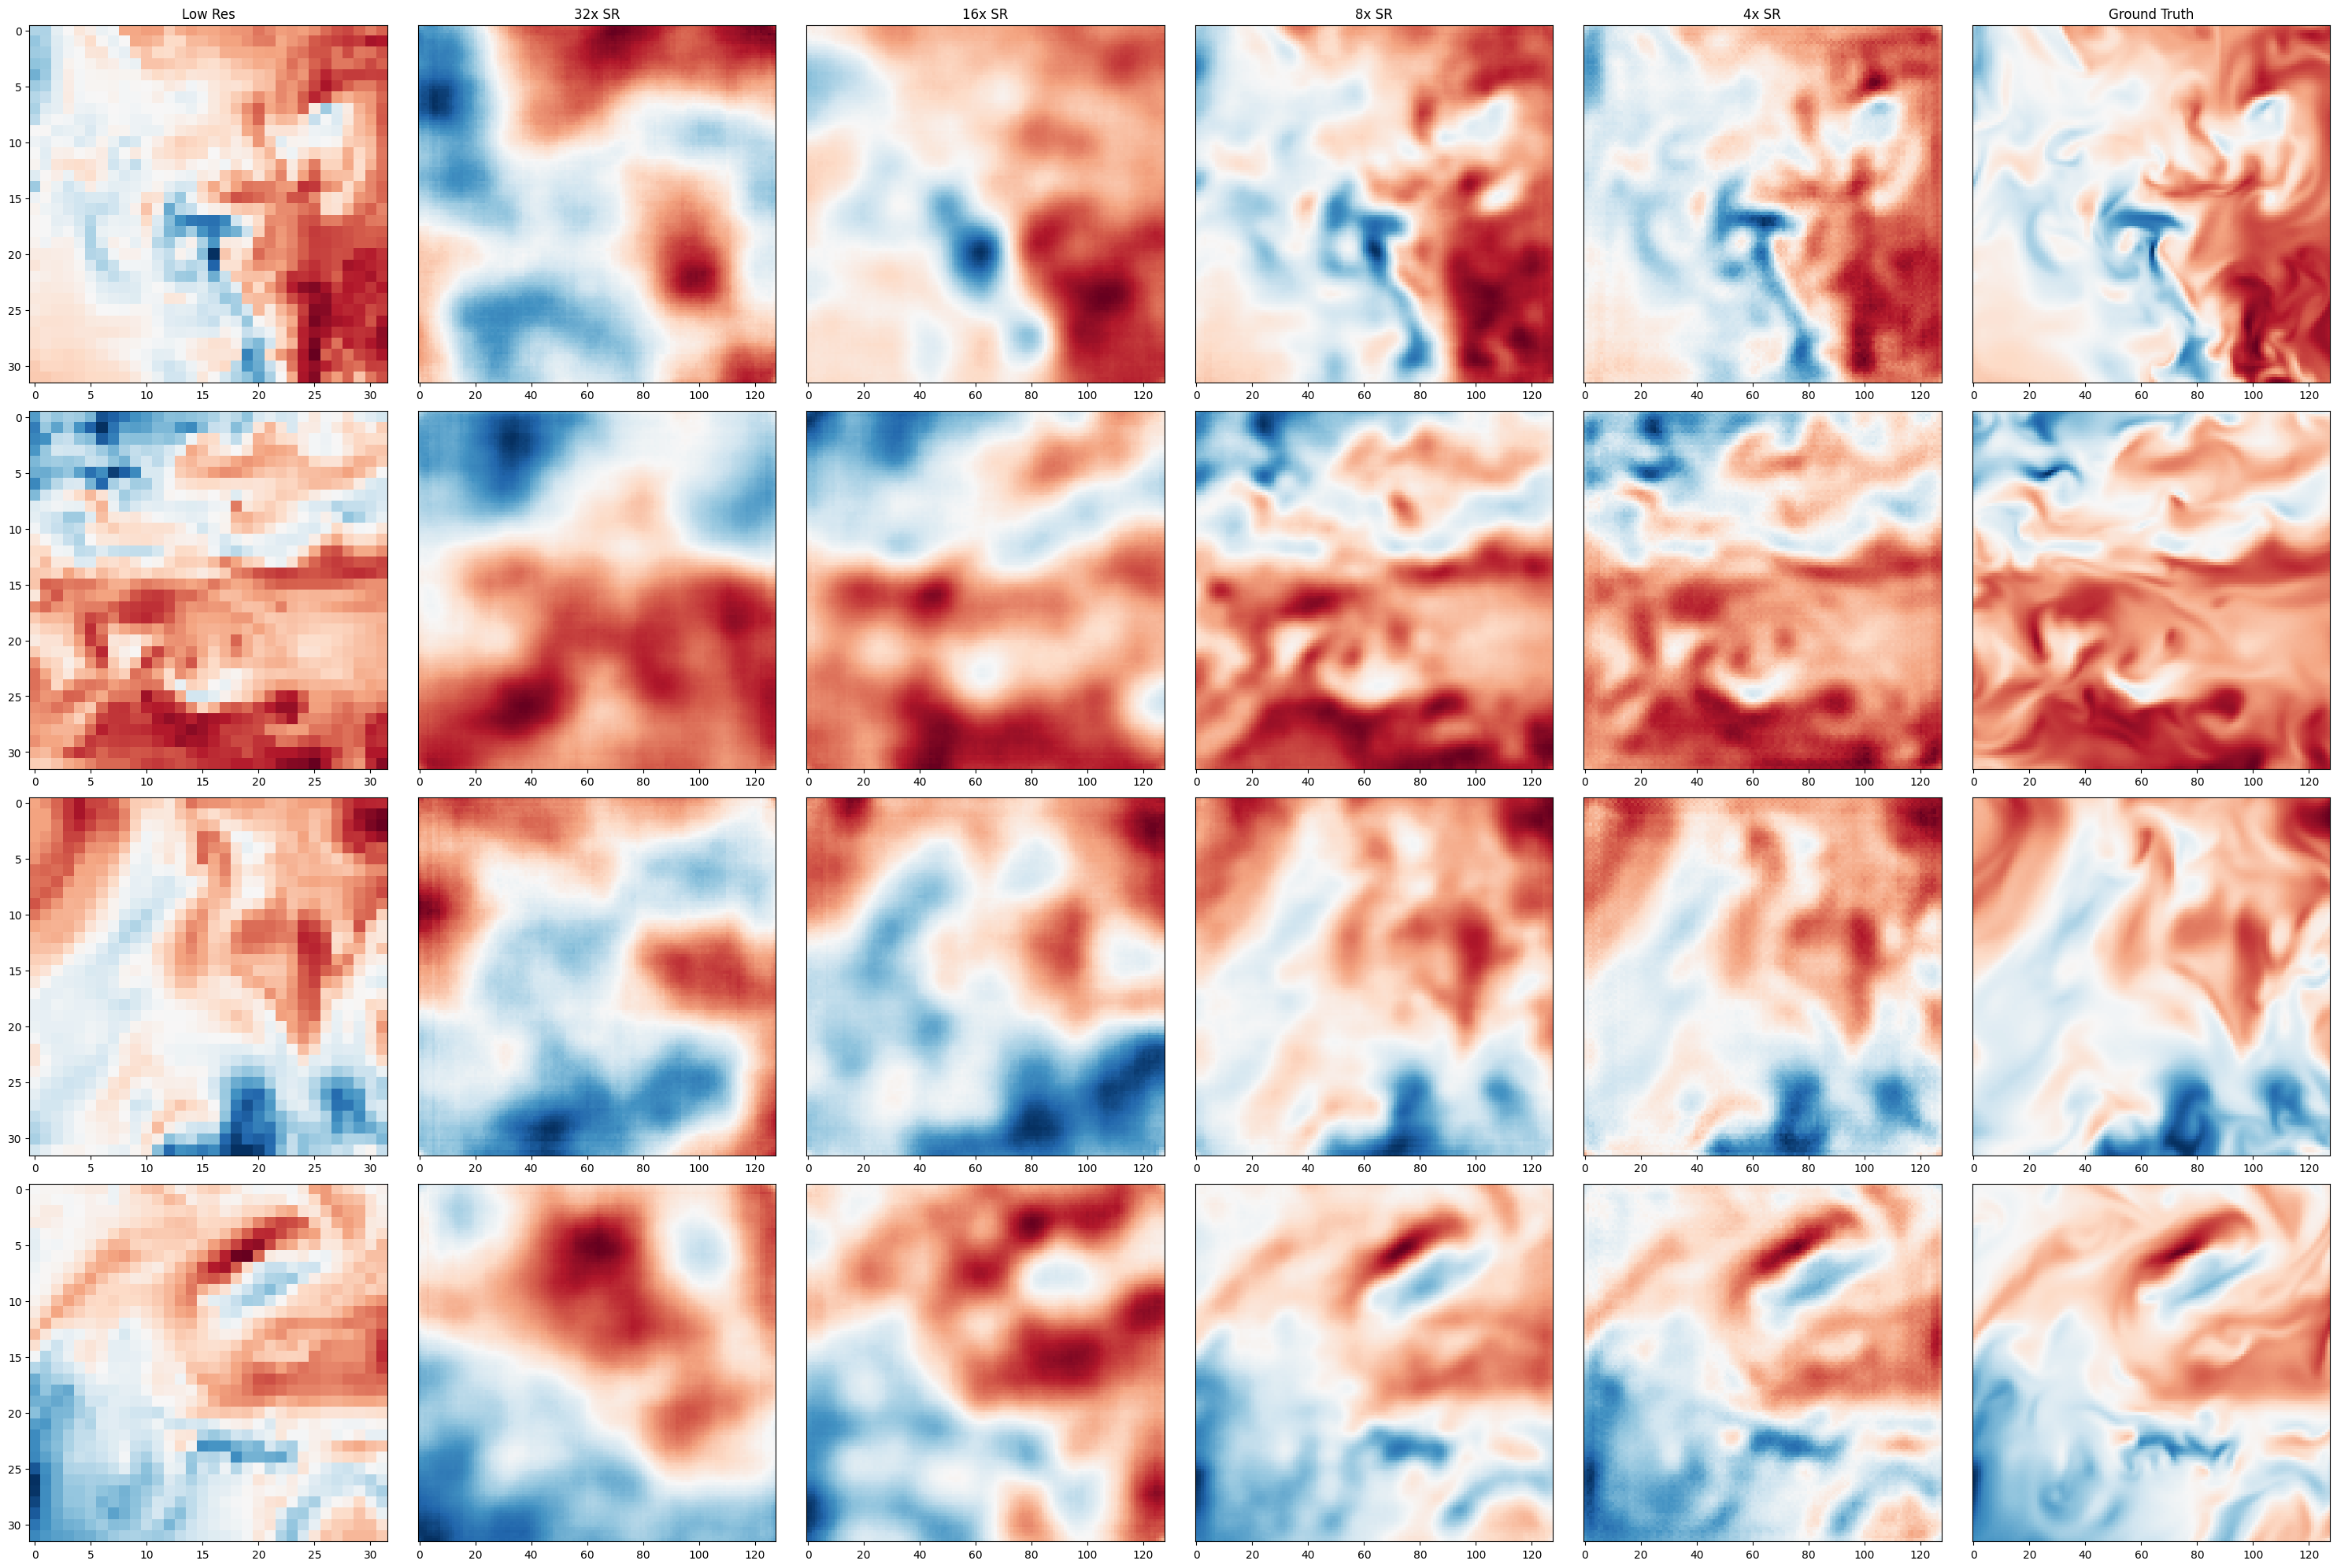

In [27]:
import matplotlib.pyplot as plt

U_lr_ref = U_lr[4]
lr_mid = U_lr_ref.shape[-1] // 2
hr_mid = U_hr_true.shape[-1] // 2

sample_indices = [0, 4, 8, 12]
labels = ["Low Res", "32x SR", "16x SR", "8x SR", "4x SR", "Ground Truth"]

fig, axs = plt.subplots(len(sample_indices), 6, figsize=(30, 20))

for row, i in enumerate(sample_indices):
    axs[row, 0].imshow(U_lr_ref.numpy()[i, 0, ..., lr_mid], cmap="RdBu_r")
    for j, sf in enumerate([32, 16, 8, 4]):
        axs[row, j + 1].imshow(U_pred[sf].numpy()[i, 0, ..., hr_mid], cmap="RdBu_r")
    axs[row, 5].imshow(U_hr_true.numpy()[i, 0, ..., hr_mid], cmap="RdBu_r")
    for col in range(1, 6):
        axs[row, col].set_yticks([])
    if row == 0:
        for col, label in enumerate(labels):
            axs[row, col].set_title(label)

plt.tight_layout()
plt.show()

From the slice plots it can be observed that the 4x super-resolution result matches the ground truth most closely, while the 32x result shows the most smoothing. Higher scaling factors produce increasingly blurred predictions, as expected given the greater information gap between input and output. In the subsequent steps, we will do some more detailed analysis of the fields.

## Plot the Q-R diagrams

Q-R diagrams form an important analysis of the turbulent flows. Q and R are the second and third invariants of the velocity gradient tensor. The first invariant typically denoted by P is zero for the incompressible turbulent flows. 

/tmp/ipykernel_8636/1498979756.py:34: UserWarning: Log scale: values of z <= 0 have been masked
  da = axs[idx].contourf(
/tmp/ipykernel_8636/1498979756.py:34: UserWarning: Log scale: values of z <= 0 have been masked
  da = axs[idx].contourf(
/tmp/ipykernel_8636/1498979756.py:34: UserWarning: Log scale: values of z <= 0 have been masked
  da = axs[idx].contourf(
/tmp/ipykernel_8636/1498979756.py:34: UserWarning: Log scale: values of z <= 0 have been masked
  da = axs[idx].contourf(
/tmp/ipykernel_8636/1498979756.py:34: UserWarning: Log scale: values of z <= 0 have been masked
  da = axs[idx].contourf(
/tmp/ipykernel_8636/1498979756.py:34: UserWarning: Log scale: values of z <= 0 have been masked
  da = axs[idx].contourf(


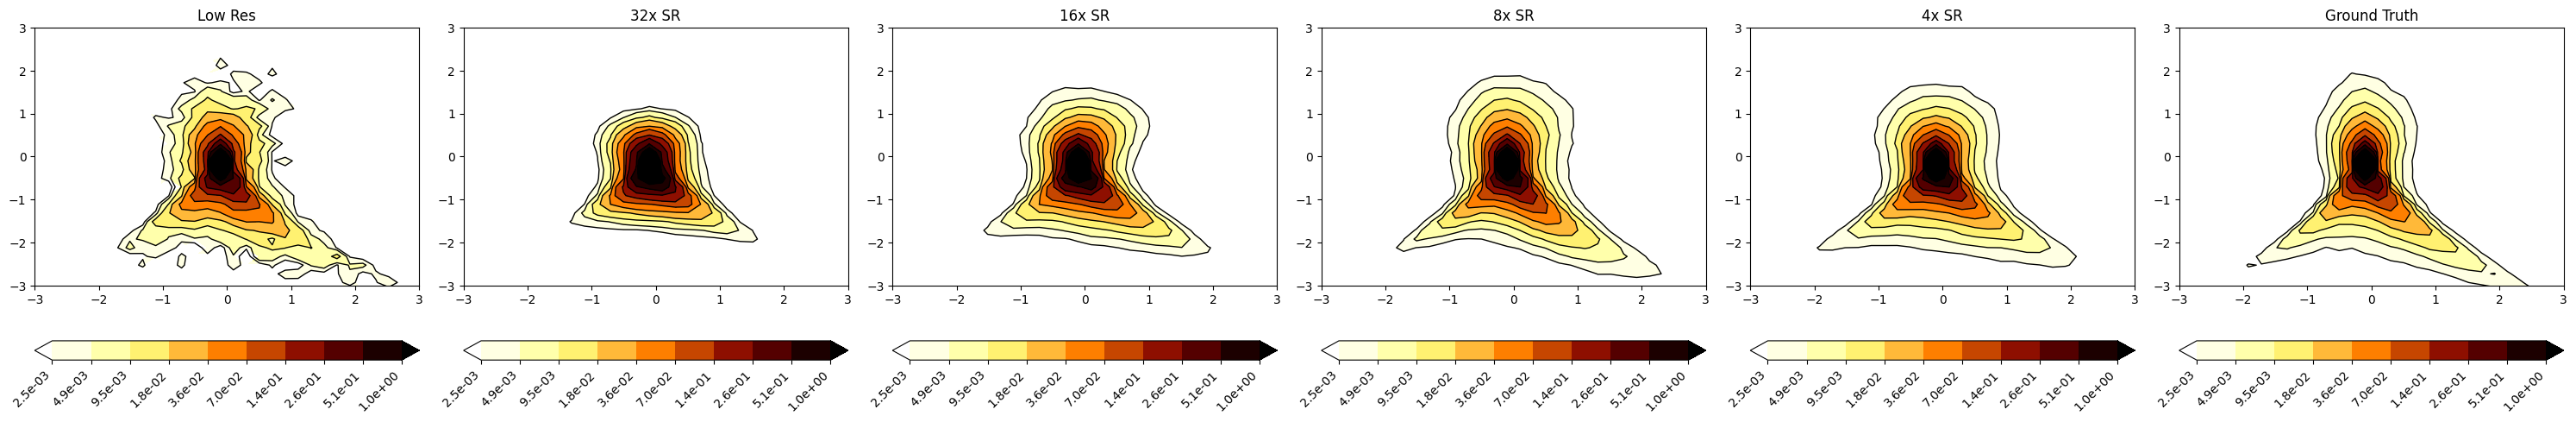

In [28]:
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.colors import LogNorm

Redges0 = np.linspace(-10.0, 10.0, num=100)
Qedges0 = np.linspace(-10.0, 10.0, num=100)
bins = (Redges0, Qedges0)
contour_levels = np.geomspace(2.5e-03, 1, num=10)

# Data in display order: low-res, 32x, 16x, 8x, 4x, ground truth
qr_data = [
    ("Low Res", r_lr, q_lr),
    ("32x SR", r_pred[32], q_pred[32]),
    ("16x SR", r_pred[16], q_pred[16]),
    ("8x SR", r_pred[8], q_pred[8]),
    ("4x SR", r_pred[4], q_pred[4]),
    ("Ground Truth", r_hr_true, q_hr_true),
]

fig, axs = plt.subplots(1, 6, figsize=(30, 5))

for idx, (label, r_data, q_data) in enumerate(qr_data):
    H, xedges, yedges = np.histogram2d(
        r_data[0].numpy().flatten(),
        q_data[0].numpy().flatten(),
        bins=bins, density=True,
    )
    x, y = np.meshgrid(xedges[:-1], yedges[:-1])

    axs[idx].contour(
        x, y, H.T, levels=contour_levels, colors="k",
        origin="lower", extend="both", linewidths=1,
    )
    da = axs[idx].contourf(
        x, y, H.T, levels=contour_levels, cmap="afmhot_r",
        origin="lower", extend="both",
        locator=ticker.LogLocator(), norm=LogNorm(),
    )
    cb = fig.colorbar(da, ax=axs[idx], orientation="horizontal", format="%.1e")
    cb.set_ticks(contour_levels)
    cb.update_ticks()
    cb.ax.set_xticklabels(cb.ax.get_xticklabels(), rotation=45, ha="right")
    axs[idx].set_title(label)
    axs[idx].set_xlim([-3, 3])
    axs[idx].set_ylim([-3, 3])

plt.tight_layout()
plt.show()

It can be observed that the 4x and 8x predictions replicate the overall teardrop shape of the Q-R plot from the ground truth. The 32x prediction, starting from much less information, shows a more diffuse structure.

## Compute continuity errors

In this section we will compute the continuity residuals in differential and integral sense.

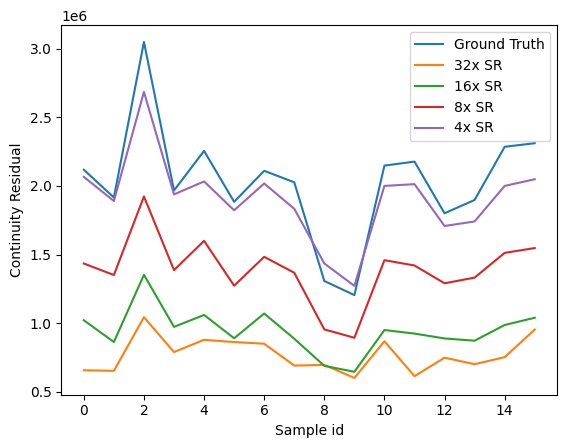

In [29]:
import matplotlib.pyplot as plt
from inference_utils import compute_continuity

true_continuity = compute_continuity(U_hr_true)
pred_continuity = {}
for sf in scaling_factors:
    pred_continuity[sf] = compute_continuity(U_pred[sf])

plt.plot(
    torch.sum(torch.abs(true_continuity), dim=(1, 2, 3, 4)).numpy(),
    label="Ground Truth",
)
for sf in [32, 16, 8, 4]:
    plt.plot(
        torch.sum(torch.abs(pred_continuity[sf]), dim=(1, 2, 3, 4)).numpy(),
        label=f"{sf}x SR",
    )
plt.ylabel("Continuity Residual")
plt.xlabel("Sample id")
plt.legend()
plt.show()

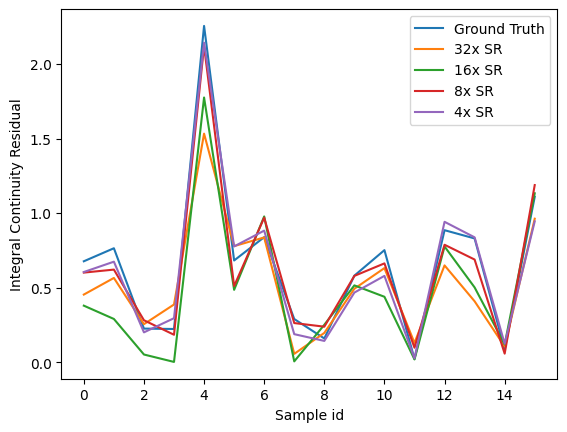

In [30]:
# Compute integral continuity
# computing outflow - inflow across the batch dimension

def compute_integral_continuity(U):
    return (
        torch.mean(U[:, 0, -1, :, :], dim=(-2, -1))
        - torch.mean(U[:, 0, 0, :, :], dim=(-2, -1))
        + torch.mean(U[:, 1, :, -1, :], dim=(-2, -1))
        - torch.mean(U[:, 1, :, 0, :], dim=(-2, -1))
        + torch.mean(U[:, 2, :, :, -1], dim=(-2, -1))
        - torch.mean(U[:, 2, :, :, 0], dim=(-2, -1))
    )

plt.plot(torch.abs(compute_integral_continuity(U_hr_true)).numpy(), label="Ground Truth")
for sf in [32, 16, 8, 4]:
    plt.plot(torch.abs(compute_integral_continuity(U_pred[sf])).numpy(), label=f"{sf}x SR")
plt.ylabel("Integral Continuity Residual")
plt.xlabel("Sample id")
plt.legend()
plt.show()

The signals with higher resolution show more errors on continuity residual. This can be attributed to the smoothness of the signal which results in effectively lower values of the velocity gradients. In an integral sense, the differences are much less visible. 

Another way to visualize the continutity errors is by plotting the histogram of the `P` (first invariant of velocity gradient tensor). For incompressible flows, the `P` should be zero. 

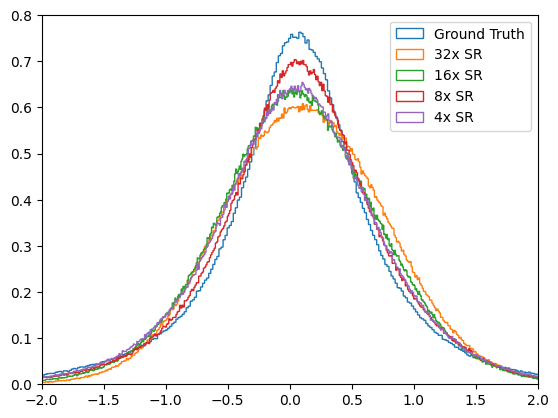

In [31]:
plt.hist(p_hr_true[0].numpy(), bins=1000, density=True, histtype="step", label="Ground Truth")
for sf in [32, 16, 8, 4]:
    plt.hist(p_pred[sf][0].numpy(), bins=1000, density=True, histtype="step", label=f"{sf}x SR")
plt.xlim([-2, 2])
plt.legend()

From the histogram plot, the ground truth signal shows the tightest distribution around zero for `P`, as expected for incompressible flow. The 4x prediction closely follows, with higher scaling factors showing progressively wider distributions. This can be attributed to the truncation errors and differences in gradient schemes — the original JHTDB simulation uses a pseudo-spectral solver on a periodic domain, while here we use finite differences on non-periodic slices.

## Compute the energy spectrum

An important aspect of analysis of turbulent flow is the analysis of its turbulent kinetic energy spectrum. In the next section, we will do the spectral analysis for each super-resolution model and see how they compare with the high resolution ground truth.

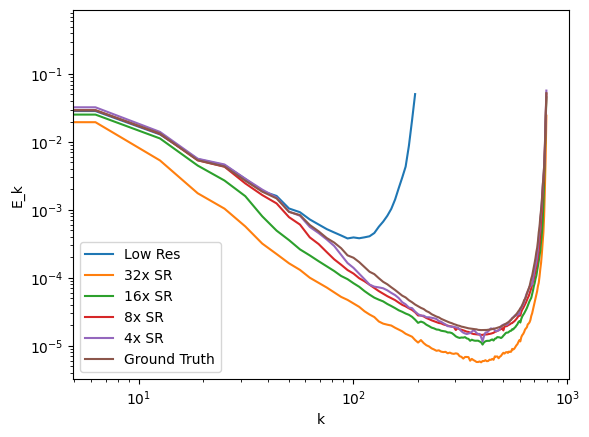

In [32]:
import matplotlib.pyplot as plt
from inference_utils import compute_tke_spectrum

lr_size = U_lr_ref.shape[-1]
hr_size = U_hr_true.shape[-1]

# Low res
_, _, wv_lr, e_lr = compute_tke_spectrum(U_lr_ref[0].numpy())
filter_lr = wv_lr < (lr_size * 2 * np.pi)

# Ground truth
_, _, wv_hr, e_hr_true = compute_tke_spectrum(U_hr_true[0].numpy())
filter_hr = wv_hr < (hr_size * 2 * np.pi)

# Predictions
wv_pred, e_pred = {}, {}
for sf in scaling_factors:
    _, _, wv_pred[sf], e_pred[sf] = compute_tke_spectrum(U_pred[sf][0].numpy())

plt.plot(wv_lr[filter_lr], e_lr[filter_lr], label="Low Res")
for sf in [32, 16, 8, 4]:
    filter_p = wv_pred[sf] < (hr_size * 2 * np.pi)
    plt.plot(wv_pred[sf][filter_p], e_pred[sf][filter_p], label=f"{sf}x SR")
plt.plot(wv_hr[filter_hr], e_hr_true[filter_hr], label="Ground Truth")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("E_k")
plt.xlabel("k")
plt.legend()
plt.show()

From the spectrum plots it can be observed that the 4x super-resolution result follows the ground truth most closely across all wave numbers. Higher scaling factors (8x, 16x, 32x) show progressively earlier drop-off at high wave numbers, reflecting the greater challenge of recovering fine-scale turbulent structure from increasingly coarse inputs.